In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def simulate_bb84(N, p_relax):
    # Generate Alice bits and bases
    alice_bits = np.random.randint(0, 2, N)
    alice_bases = np.random.randint(0, 2, N)
    
    # Generate Bob bases
    bob_bases = np.random.randint(0, 2, N)
    
    # Apply noise
    noisy_bits = []
    for bit in alice_bits:
        if bit == 1:
            if np.random.random() < p_relax:
                noisy_bits.append(0)
            else:
                noisy_bits.append(1)
        else:
            noisy_bits.append(0)
    noisy_bits = np.array(noisy_bits)
    
    # Measure
    bob_results = []
    for noisy_bit, a_basis, b_basis in zip(noisy_bits, alice_bases, bob_bases):
        if a_basis == b_basis:
            bob_results.append(noisy_bit)
        else:
            bob_results.append(np.random.randint(0, 2))
            
    # Sift
    sifted_alice = []
    sifted_bob = []
    for i in range(N):
        if alice_bases[i] == bob_bases[i]:
            sifted_alice.append(int(alice_bits[i]))
            sifted_bob.append(int(bob_results[i]))
            
    # Compute QBER
    errors = 0
    for a, b in zip(sifted_alice, sifted_bob):
        if a != b:
            errors += 1
            
    qber = errors / len(sifted_alice) if len(sifted_alice) > 0 else 0
    
    return {
        "qber": qber,
        "errors": errors,
        "sifted_length": len(sifted_alice)
    }


In [16]:
qber_dict = simulate_bb84( 
    N=1000,
    p_relax=0.05
)

print(qber_dict)


{'qber': 0.02263374485596708, 'errors': 11, 'sifted_length': 486}


In [17]:
results = []

for p_relax in np.arange(0, 0.31, 0.01):
    qbers = []
    # Run BB84 20 times
    for _ in range(20):
        res = simulate_bb84(N=1000, p_relax=p_relax)
        qbers.append(res['qber'])
    
    # Average QBER
    avg_qber = np.mean(qbers)
    # Store Result
    results.append({
        'p_relax': p_relax,
        'avg_qber': avg_qber
    })


In [18]:
df = pd.DataFrame(results)
df.head(6)


,p_relax,avg_qber
0,0.00,0.000000
1,0.01,0.005257
2,0.02,0.009926
3,0.03,0.015894
4,0.04,0.020973
5,0.05,0.025049


In [11]:
df.to_csv(
    "../data/qber_dataset.csv",
    index=False
)


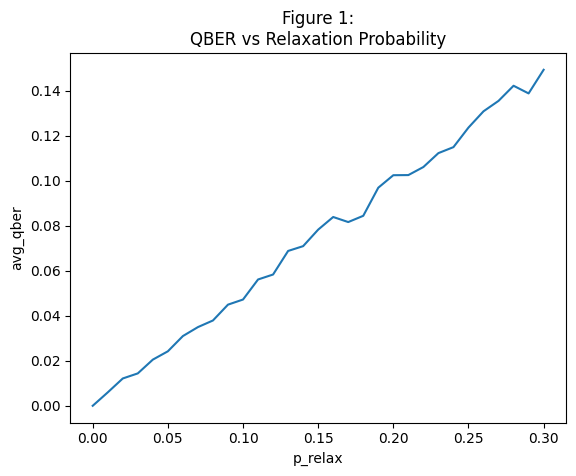

In [12]:
plt.plot(
    df["p_relax"],
    df["avg_qber"]
)
plt.title("Figure 1:\nQBER vs Relaxation Probability")
plt.xlabel("p_relax")
plt.ylabel("avg_qber")
plt.show()
